In [27]:
import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
dataset_root_dir = '../raw_dataset'
manual_dataset_root_dir = '../gen_data'

dataset_dirs = ['Folio', 'LogiQA', 'ProofWriter', 'ReClor', 'RuleTaker']

dataset_dfs = []
for dir in dataset_dirs:
    for partition in ['train', 'valid', 'test']:
        path = os.path.join(dataset_root_dir, dir, f'{dir.lower()}_{partition}.json')
        if not os.path.isfile(path):
            print(f'[INFO]: {path} is not existed')
            continue
        
        df = pd.read_json(path)
        df = df.rename(columns=lambda x: x.replace('premise', 'premises').replace('premisess', 'premises'))
        df = df[['id', 'nat_premises', 'label']]
        df = df.rename(columns={'nat_premises': 'premises'})
        
        df['source_name'] = dir.lower()
        df['partition'] = partition
        
        dataset_dfs.append(df)

# for file_name in ['Folio/folio_test.json', 'ReClor/reclor_test.json', 'LogiQA/logiqa_test.json']:
#     path = os.path.join(dataset_root_dir, file_name)
#     if not os.path.isfile(path):
#             print(f'[INFO]: {path} is not existed')
#             continue
        
#     df = pd.read_json(path)
#     df = df.rename(columns=lambda x: x.replace('premise', 'premises').replace('premisess', 'premises'))
#     df = df[['id', 'nat_premises', 'label']]
#     df = df.rename(columns={'nat_premises': 'premises'})
    
#     df['source_name'] = file_name.split('/')[0].lower()
#     df['partition'] = 'test'
#     dataset_dfs.append(df)
    
for file_name in os.listdir(manual_dataset_root_dir):
    path = os.path.join(manual_dataset_root_dir, file_name)
    if not os.path.isfile(path):
            print(f'[INFO]: {path} is not existed')
            continue
        
    df = pd.read_json(path)
    df = df[['id', 'premises', 'label']]
    
    df['source_name'] = 'manual'
    df['partition'] = 'test'
    dataset_dfs.append(df)
    
df = pd.concat(dataset_dfs, ignore_index=True)

In [29]:
df['partition'].value_counts()

partition
train    97361
test     25901
valid    13187
Name: count, dtype: int64

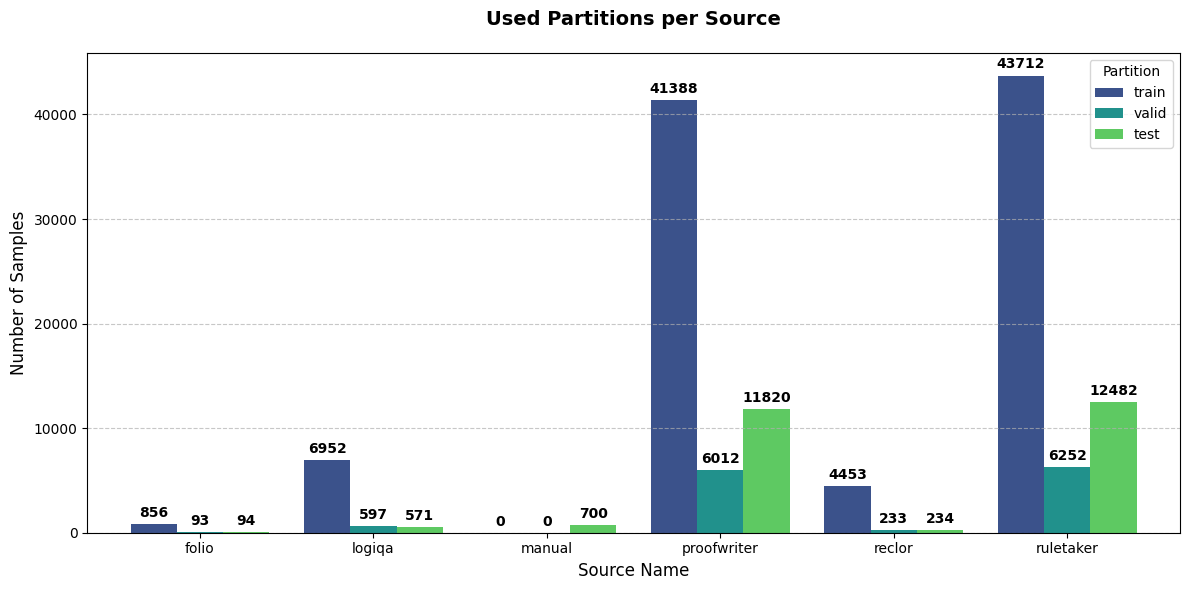

In [30]:
palette = sns.color_palette("viridis", 3)

pivot_df = pd.crosstab(df['source_name'], df['partition'])
desired_order = ['train', 'valid', 'test']
pivot_df = pivot_df.reindex(columns=desired_order, fill_value=0)
ax = pivot_df.plot(kind='bar', figsize=(12, 6), color=palette, width=0.8)

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.title('Used Partitions per Source', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Source Name', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Partition', loc='upper right', frameon=True)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

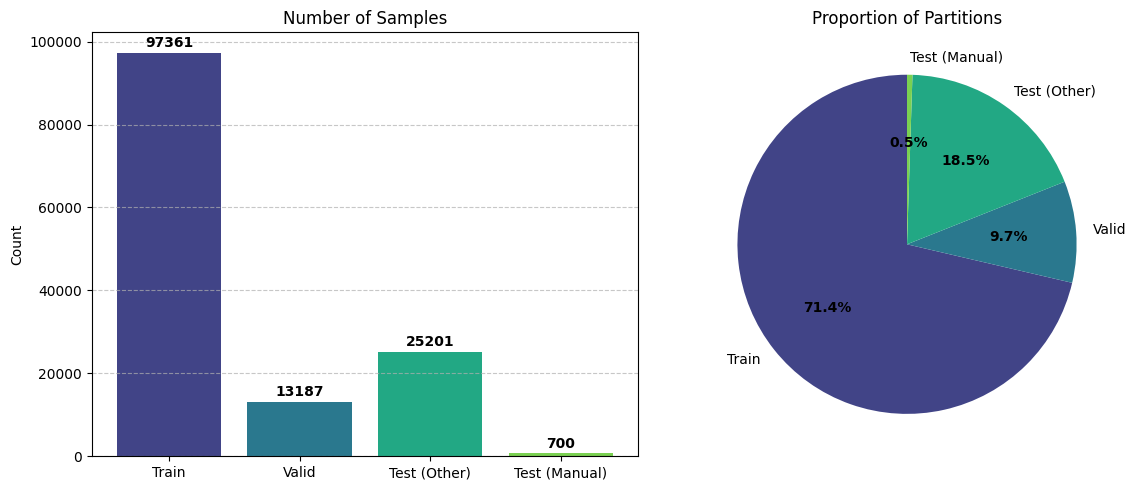

In [31]:
# Number of samples
train_count = len(df[df['partition'] == 'train'])
valid_count = len(df[df['partition'] == 'valid'])

test_df = df[df['partition'] == 'test']
test_manual = len(test_df[test_df['source_name'] == 'manual'])
test_other = len(test_df[test_df['source_name'] != 'manual'])

s_counts = pd.Series({
    'Train': train_count,
    'Valid': valid_count,
    'Test (Other)': test_other,
    'Test (Manual)': test_manual
})

palette = sns.color_palette("viridis", len(s_counts))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
bars = ax1.bar(s_counts.index, s_counts.values, color=palette)
ax1.bar_label(bars, padding=2, fontsize=10, fontweight='bold')
ax1.set_title('Number of Samples')
ax1.set_ylabel('Count')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.xaxis.grid(False)

patches, texts, autotexts = ax2.pie(
    s_counts.values, 
    labels=s_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=palette,
    wedgeprops={'linewidth': 0.2, 'edgecolor': 'none'}
)
for autotext in autotexts:
    autotext.set_weight('bold')
    autotext.set_color('black')

ax2.set_title('Proportion of Partitions')

plt.tight_layout()
plt.show()

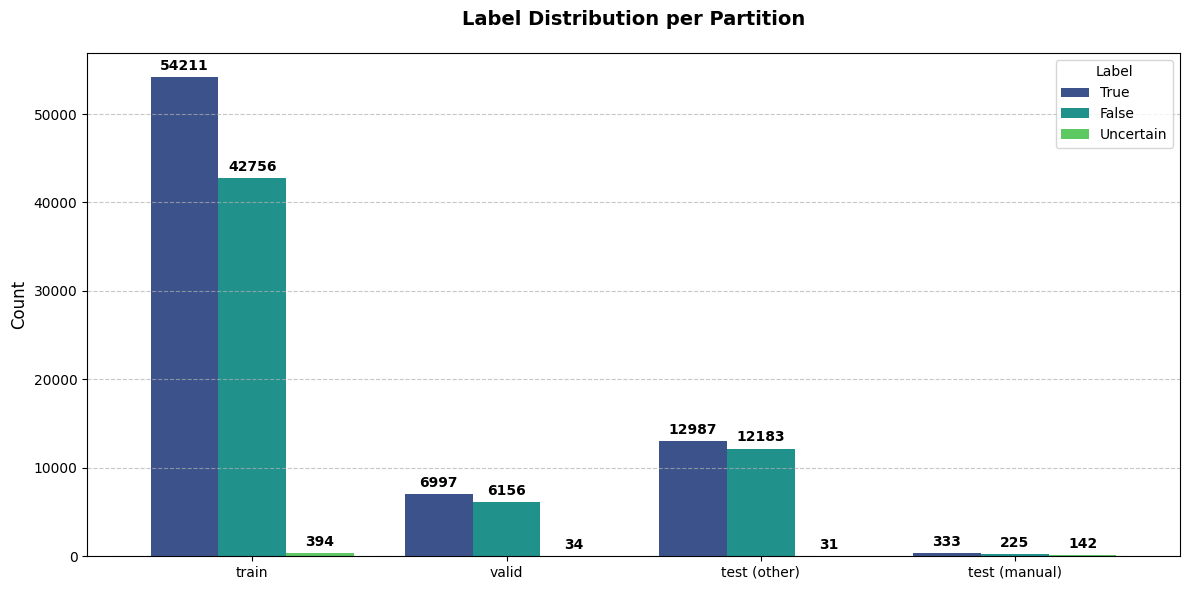

In [32]:
df['plot_partition'] = df.apply(
    lambda x: f"test ({x['source_name']})" if x['partition'] == 'test' and x['source_name'] == 'manual'
    else ("test (other)" if x['partition'] == 'test' else x['partition']), 
    axis=1
)

label_df = pd.crosstab(df['plot_partition'], df['label'])

desired_labels = ['True', 'False', 'Uncertain']
desired_partitions = ['train', 'valid', 'test (other)', 'test (manual)']

label_df = label_df.reindex(columns=desired_labels, fill_value=0)
label_df = label_df.reindex(index=desired_partitions, fill_value=0)

palette = sns.color_palette("viridis", 3)
ax = label_df.plot(kind='bar', figsize=(12, 6), color=palette, width=0.8)
ax.set_xlabel('')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.title('Label Distribution per Partition', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Label', loc='upper right', frameon=True)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

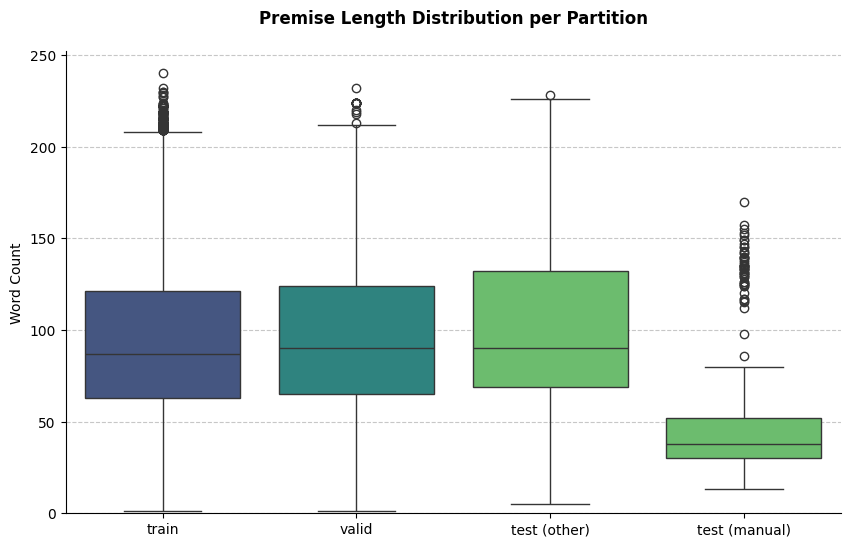

In [33]:
df['plot_partition'] = df.apply(
    lambda x: f"test ({x['source_name']})" if x['partition'] == 'test' and x['source_name'] == 'manual'
    else ("test (other)" if x['partition'] == 'test' else x['partition']), 
    axis=1
)

df['word_count'] = df['premises'].str.split().str.len()
desired_order = ['train', 'valid', 'test (other)', 'test (manual)']

plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x='plot_partition', y='word_count', hue='partition', palette='viridis', order=desired_order, legend=False)
ax.set_ylim(bottom=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.title('Premise Length Distribution per Partition', fontweight='bold', pad=20)
plt.ylabel('Word Count')
plt.xlabel('') 
sns.despine()
plt.show()